In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 
import pydot

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import Activation, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
fashion_train = pd.read_csv("fashion-mnist_train.csv")
fashion_test = pd.read_csv("fashion-mnist_test.csv")

In [3]:
fashion_train.shape

(60000, 785)

In [4]:
X_train_fashion = fashion_train.drop('label', axis = 1)
y_train_fashion = fashion_train['label']
X_test_fashion = fashion_test.drop('label', axis = 1)
y_test_fashion = fashion_test['label']

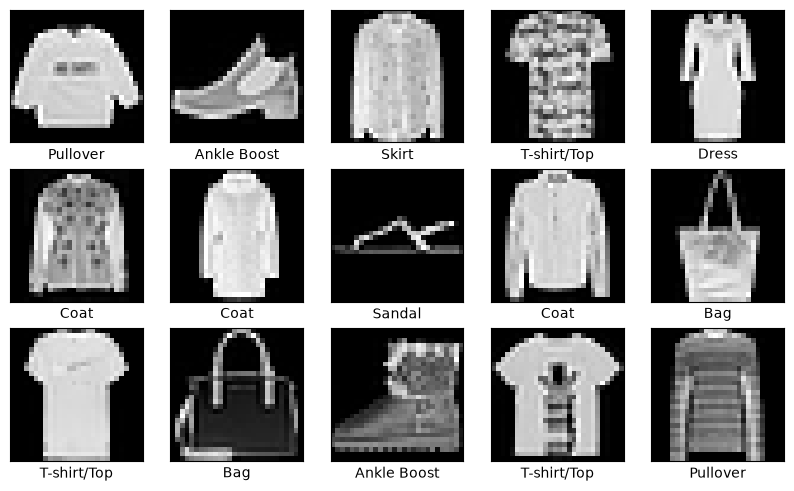

In [5]:
#Reshaping the Dataset
X_train_reshape = X_train_fashion.values.reshape(-1, 28, 28)
X_train_reshape = X_train_fashion.values.reshape(-1, 28, 28)

#Names of clothing accessories in order
col_names = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Skirt', 'Sneaker', 'Bag', 'Ankle Boost']

# visualizing the image:
plt.figure(figsize=(10, 10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [6]:
y_train_fashion = to_categorical(y_train_fashion, num_classes = 10)

y_test_fashion = to_categorical(y_test_fashion, num_classes = 10)

In [7]:
#creating Base neural network

model = keras.Sequential([ layers.Dense(128, activation ='relu', input_shape=(784,)),
                          layers.Dropout(0.3),layers.BatchNormalization(),
                          layers.Dense(24, activation ='relu'),
                          layers.Dropout(0.3),layers.BatchNormalization(),
                          layers.Dense(24, activation = 'relu'),
                          layers.Dropout(0.3), layers.BatchNormalization(),
                          layers.Dense(10, activation='softmax'),])

# Compiling the model 

model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics =['accuracy'])

# Fitting the model

history = model.fit(X_train_fashion, y_train_fashion, batch_size =100, epochs=30, validation_data = (X_test_fashion, y_test_fashion))
                                       
                          

C:\Anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6146 - loss: 1.1191 - val_accuracy: 0.8229 - val_loss: 0.5322
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7442 - loss: 0.7422 - val_accuracy: 0.8293 - val_loss: 0.5362
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7639 - loss: 0.6850 - val_accuracy: 0.8384 - val_loss: 0.4797
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7826 - loss: 0.6390 - val_accuracy: 0.8443 - val_loss: 0.4715
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7938 - loss: 0.6095 - val_accuracy: 0.8545 - val_loss: 0.4389
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8001 - loss: 0.5910 - val_accuracy: 0.8552 - val_loss: 0.4375
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8015 - loss: 0.5880 - val_accuracy: 0.8583 - val_loss: 0.4780
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8087 - loss: 0.5743 - val_accuracy: 0.

In [8]:
test_loss_fashion, test_acc_fashion = model.evaluate(X_test_fashion, y_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8701 - loss: 0.4194


In [9]:
print("Fashion Mnist Test Accuracy:", round(test_acc_fashion,4))

Fashion Mnist Test Accuracy: 0.8701


In [10]:
# Predicting the label fashion:

y_predict_fash = model.predict(X_test_fashion)
y_predict_fash = np.argmax(y_predict_fash, axis=1)
y_test_fash_eval = np.argmax(y_test_fashion, axis =1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


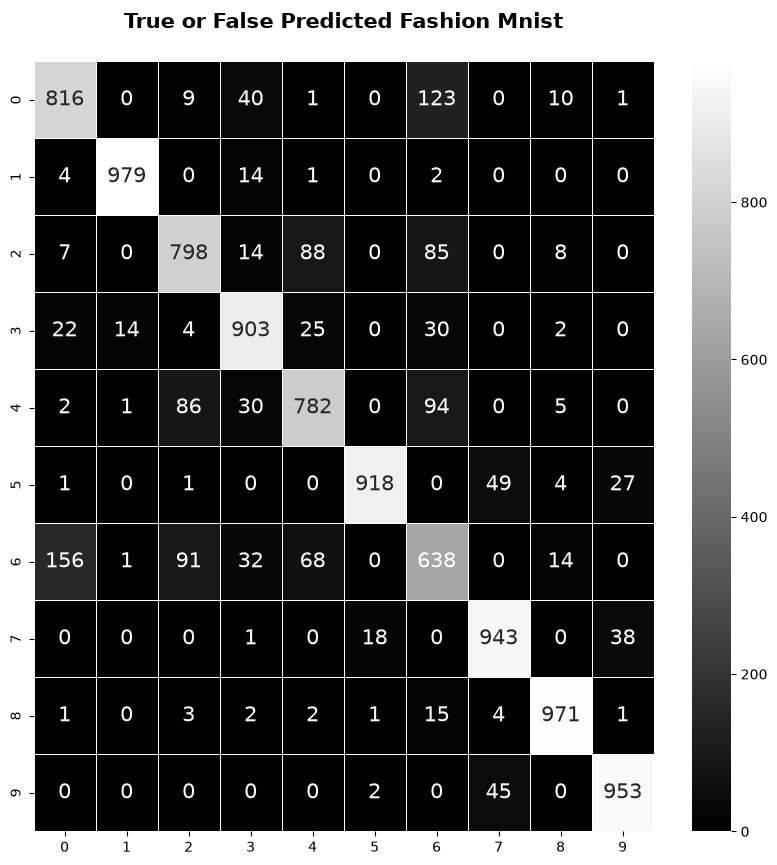

In [11]:
con_mat = confusion_matrix(y_test_fash_eval, y_predict_fash)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True, annot_kws={'size' : 15}, linewidths=0.5, fmt="d", cmap="gray")
plt.title("True or False Predicted Fashion Mnist\n", fontweight='bold', fontsize=15)
plt.show()

In [12]:
from sklearn.metrics import classification_report 
print(classification_report(y_test_fash_eval, y_predict_fash))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1000
           1       0.98      0.98      0.98      1000
           2       0.80      0.80      0.80      1000
           3       0.87      0.90      0.89      1000
           4       0.81      0.78      0.80      1000
           5       0.98      0.92      0.95      1000
           6       0.65      0.64      0.64      1000
           7       0.91      0.94      0.92      1000
           8       0.96      0.97      0.96      1000
           9       0.93      0.95      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [13]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


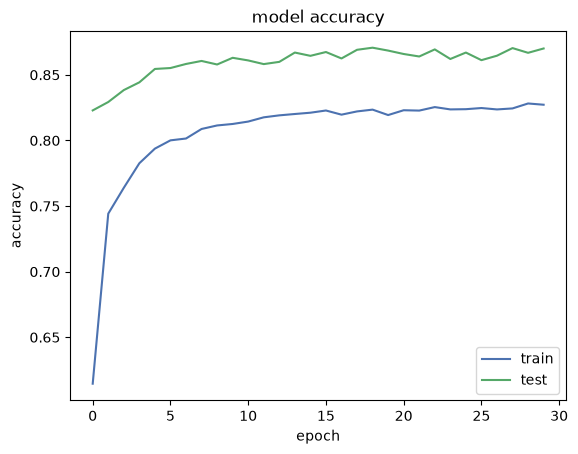

In [14]:
# summarise history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'], loc = 'best')
plt.show()

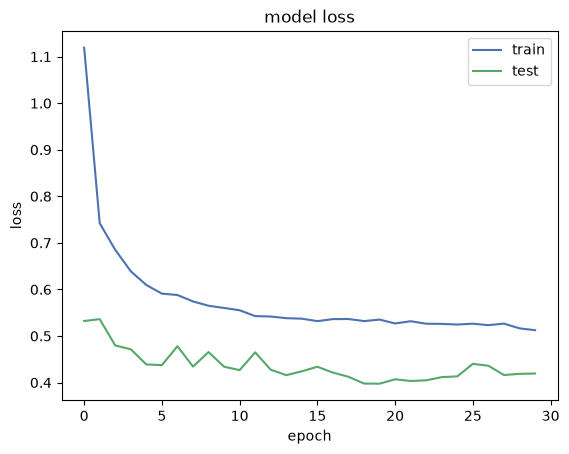

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [16]:
#tf.expend_dims(X_test_digit[0]):
y_predict = model.predict(X_test_fashion.loc[[0],:].values)
y_predict = np.argmax(y_predict, axis = 1)
y_test_digit_eval =np.argmax(y_test_fashion, axis =1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


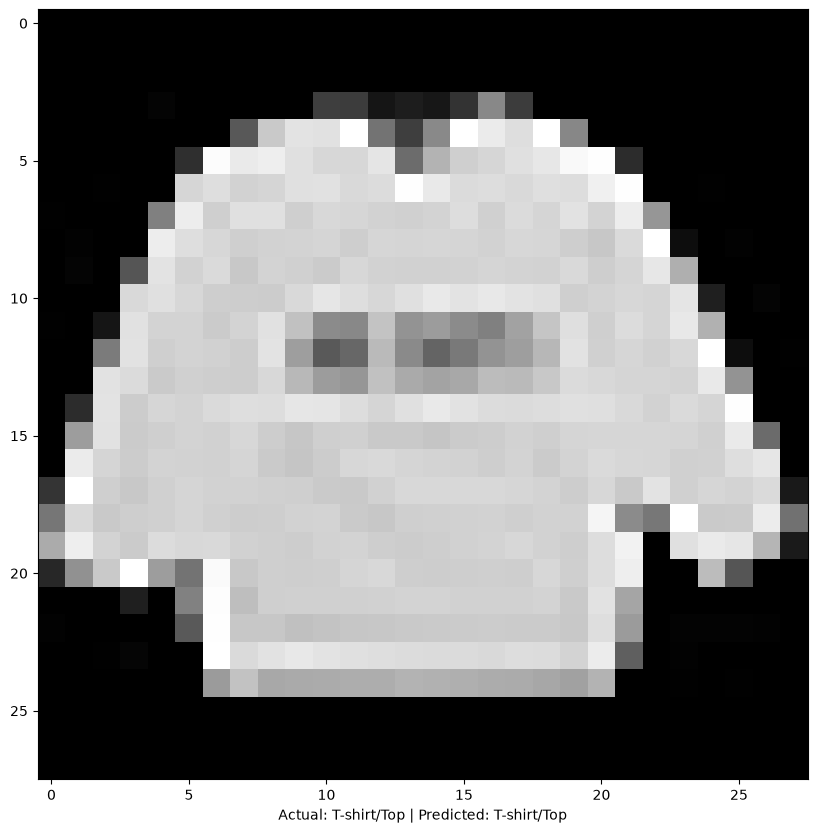

In [17]:
#Names of clothing accessories in order
col_names = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Skirt', 'Sneaker', 'Bag', 'Ankle Boost']

# visualizing the image:

plt.figure(figsize=(10,10))

plt.imshow(X_train_reshape[0], cmap='gray')
plt.xlabel("Actual: {} | Predicted: {}". format(col_names[np.argmax(y_test_fashion[0])], col_names[y_predict[0]]))
plt.show()